In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Age Estimation using Transfer Learning (ResNet18)

In this project, we aim to predict an individual's age from facial images. We utilize **Transfer Learning** with a pre-trained **ResNet18** model. Given the complexity of facial features across different ages, leveraging a model pre-trained on massive datasets (like ImageNet) significantly improves accuracy and convergence speed compared to training from scratch.

In [36]:
from torch.utils.data import DataLoader,Dataset
import torch.nn as nn
import torch
import os
from PIL import Image
from torchvision import transforms,models
from sklearn.model_selection import train_test_split
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision.transforms import functional as F

In [25]:
class UTKFaceDataset(Dataset):
    def __init__(self, root, files=None, transform=None, max_age=100):
        self.root = root
        self.transform = transform
        self.max_age = max_age

      
        if files is None:
            files = os.listdir(root)
        self.images = []

        for fname in files:
            if not fname.lower().endswith(".jpg"):
                continue
            try:
                age = int(fname.split('_')[0])
            except:
                continue
            if age <= self.max_age:
                self.images.append(fname)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_name = self.images[idx]
        image_path = os.path.join(self.root, image_name)
        image = Image.open(image_path).convert('RGB')
        age = float(image_name.split('_')[0]) 

        if self.transform:
            image = self.transform(image)

        return image, age

In [26]:
root='/kaggle/input/utkface-new/UTKFace'
all_images=os.listdir(root)
train_images,test_images=train_test_split(all_images,test_size=0.2)
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train_dataset = UTKFaceDataset(root, files=train_images, transform=train_transform)
test_dataset  = UTKFaceDataset(root, files=test_images, transform=test_transform)


## Model Architecture & Training Setup

In this section, we load the **ResNet18** model and apply the following modifications for our regression task:
* **Fine-tuning:** All model parameters are set to `requires_grad = True` to adapt the pre-trained weights to facial specific features.
* **Final Layer Modification:** The original Fully Connected (FC) layer is replaced with a linear layer having **1 output neuron** (representing the predicted age).
* **Loss Function:** We use `SmoothL1Loss`, which is more robust to outliers in regression tasks compared to MSE.
* **Optimizer:** The **Adam** optimizer is initialized with a learning rate of $1e-4$ for stable optimization.

In [27]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

criterion = nn.SmoothL1Loss()


optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

for epoch in range(5):  
    model.train()
    running_loss = 0.0
    for images, ages in train_loader:
        images = images.to(device)
        ages = ages.to(device).unsqueeze(1) 

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, ages)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}, Train Loss: {epoch_loss:.4f}")


Epoch 1, Train Loss: 15.3146
Epoch 2, Train Loss: 5.6866
Epoch 3, Train Loss: 5.0814
Epoch 4, Train Loss: 4.6744
Epoch 5, Train Loss: 4.2687


In [29]:
model.eval()  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

all_preds = []
all_ages = []

with torch.no_grad():
    for images, ages in test_loader:
        images = images.to(device)
        ages = ages.to(device).unsqueeze(1)

        outputs = model(images)

        all_preds.append(outputs.cpu())
        all_ages.append(ages.cpu())


all_preds = torch.cat(all_preds, dim=0)
all_ages  = torch.cat(all_ages, dim=0)


mae = torch.mean(torch.abs(all_preds - all_ages))
print(f"Test MAE: {mae:.4f} years")


Test MAE: 4.9444 years


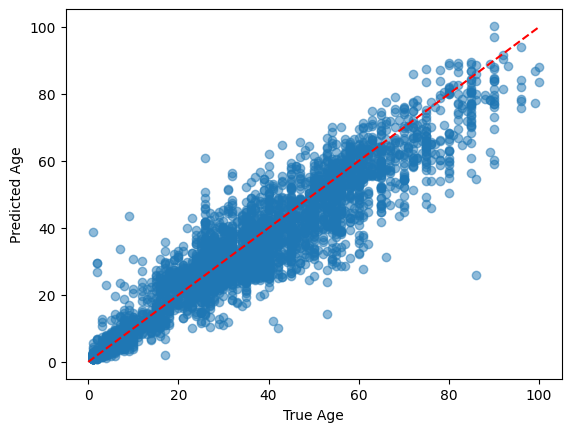

In [30]:
plt.scatter(all_ages, all_preds, alpha=0.5)
plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.plot([0, 100], [0, 100], 'r--')  
plt.show()

## Final Results & Analysis

Based on the training process and the final evaluation, we can draw the following conclusions:

* **Training Convergence:** The model showed a healthy learning curve, with the training loss decreasing consistently from **15.31** (Epoch 1) to **4.26** (Epoch 5).
* **Accuracy:** The model achieved a **Mean Absolute Error (MAE) of 4.94 years** on the test set. This means that, on average, the AI's prediction is only about 5 years off from the person's actual age.
* **Scatter Plot Analysis:** * The visualization shows a strong linear correlation between the **True Age** and **Predicted Age**, as most data points cluster closely around the red dashed line ($y = x$).
    * The model performs exceptionally well for middle-aged groups, while the slight variance in extreme age groups (very young or very old) is a common challenge in facial age estimation.
* **Summary:** Given that we only used 5 epochs and a standard ResNet18, the result is highly successful. The performance confirms that **Transfer Learning** is extremely effective for regression-based computer vision tasks.